In [1]:

import numpy as np

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [2]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self, input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput  # Исправлено: было self.gradInpu

    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case: 

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Sequential container

**Define** a forward and backward pass procedures.

In [3]:
class Sequential(Module):
    def __init__(self):
        super(Sequential, self).__init__()
        self.modules = []
    
    def add(self, module):
        self.modules.append(module)
    
    def updateOutput(self, input):
        self.intermediate = [input]  
        current = input
        for i, module in enumerate(self.modules):
            current = module.forward(current)
            self.intermediate.append(current)
        self.output = current
        return self.output
    
    def backward(self, input, gradOutput):
        grad = gradOutput
        for i in range(len(self.modules) - 1, -1, -1):
            grad = self.modules[i].backward(self.intermediate[i], grad)
        self.gradInput = grad
        return self.gradInput
    
    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()
    
    def getParameters(self):
        params = []
        for module in self.modules:
            params.extend(module.getParameters())
        return params
    
    def getGradParameters(self):
        grads = []
        for module in self.modules:
            grads.extend(module.getGradParameters())
        return grads
    
    def train(self):
        self.training = True
        for module in self.modules:
            module.train()
    
    def evaluate(self):
        self.training = False
        for module in self.modules:
            module.evaluate()
    
    def __repr__(self):
        return "\n".join([str(m) for m in self.modules])
    
    def __getitem__(self, idx):
        return self.modules[idx]

# Layers

## 1 (0.2). Linear transform layer
Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [4]:
class Linear(Module):
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size=(n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size=n_out)
        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)
    def updateOutput(self, input):
        self.input = input
        self.output = input @ self.W.T + self.b
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput @ self.W
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradW += gradOutput.T @ input
        self.gradb += gradOutput.sum(axis=0)

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        return 'Linear %d -> %d' % (self.W.shape[1], self.W.shape[0])

## 2. (0.2) SoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [5]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        exp = np.exp(self.output)
        self.output = exp / exp.sum(axis=1, keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        s = self.output
        self.gradInput = s * (gradOutput - (gradOutput * s).sum(axis=1, keepdims=True))
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

## 3. (0.2) LogSoftMax
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [6]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        log_sum_exp = np.log(np.exp(self.output).sum(axis=1, keepdims=True))
        self.output = self.output - log_sum_exp
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        softmax = np.exp(self.output)
        self.gradInput = gradOutput - softmax * gradOutput.sum(axis=1, keepdims=True)
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

## 4. (0.3) Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [7]:
class BatchNormalization(Module):
    EPS = 1e-3

    def __init__(self, alpha=0.9):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None
        self.batch_mean = None
        self.batch_var = None
        self.x_centered = None
        self.std_inv = None

    def updateOutput(self, input):
        if self.training:
            self.batch_mean = np.mean(input, axis=0)
            self.batch_var = np.var(input, axis=0)

            self.x_centered = input - self.batch_mean
            self.std_inv = 1.0 / np.sqrt(self.batch_var + self.EPS)

            self.output = self.x_centered * self.std_inv

            if self.moving_mean is None:
                self.moving_mean = self.batch_mean.copy()
                self.moving_variance = self.batch_var.copy()
            else:
                self.moving_mean = self.alpha * self.moving_mean + (1 - self.alpha) * self.batch_mean
                self.moving_variance = self.alpha * self.moving_variance + (1 - self.alpha) * self.batch_var
        else:
            self.output = (input - self.moving_mean) / np.sqrt(self.moving_variance + self.EPS)

        return self.output

    def updateGradInput(self, input, gradOutput):
        if self.training and self.std_inv is not None:
            N = input.shape[0]
            x_centered = input - self.batch_mean
            std_inv = self.std_inv

            dvar = np.sum(gradOutput * x_centered * -0.5 * std_inv**3, axis=0)
            dmean = (
                np.sum(gradOutput * -std_inv, axis=0)
                + dvar * np.sum(-2 * x_centered, axis=0) / N
            )

            self.gradInput = (
                gradOutput * std_inv
                + dvar * (2 * x_centered / N)
                + dmean / N
            )
        else:
            self.gradInput = gradOutput / np.sqrt(self.moving_variance + self.EPS)

        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        pass

    def zeroGradParameters(self):
        pass

    def getParameters(self):
        return []

    def getGradParameters(self):
        return []

    def __repr__(self):
        return "BatchNormalization" 

In [8]:
class ChannelwiseScaling(Module):
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()
        stdv = 1. / np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)
        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta += np.sum(gradOutput, axis=0)
        self.gradGamma += np.sum(gradOutput * input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 5. (0.3) Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [9]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        if self.training:
            self.mask = (np.random.rand(*input.shape) > self.p) / (1 - self.p)
            self.output = input * self.mask
        else:
            self.output = input
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        if self.training:
            self.gradInput = gradOutput * self.mask
        else:
            self.gradInput = gradOutput
        return self.gradInput

    def __repr__(self):
        return "Dropout"

#6. (2.0) Conv2d
Implement [**Conv2d**](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). Use only this list of parameters: (in_channels, out_channels, kernel_size, stride, padding, bias, padding_mode) and fix dilation=1 and groups=1.

In [10]:
class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True, padding_mode='zeros'):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding
        self.padding_mode = padding_mode
        
        stdv = 1. / np.sqrt(in_channels * self.kernel_size[0] * self.kernel_size[1])
        self.weight = np.random.uniform(-stdv, stdv, (out_channels, in_channels, *self.kernel_size))
        self.bias = np.random.uniform(-stdv, stdv, out_channels) if bias else None
        self.gradWeight = np.zeros_like(self.weight)
        self.gradBias = np.zeros_like(self.bias) if bias else None
        
        self.input = None
        self.x_cols = None

    def _get_padding(self, H, W):
        k_h, k_w = self.kernel_size
        s_h, s_w = self.stride
        
        if self.padding == 'same':
            out_h = (H + s_h - 1) // s_h
            out_w = (W + s_w - 1) // s_w
            pad_h = max((out_h - 1) * s_h + k_h - H, 0)
            pad_w = max((out_w - 1) * s_w + k_w - W, 0)
            return pad_h // 2, pad_h - pad_h // 2, pad_w // 2, pad_w - pad_w // 2
        elif self.padding == 'valid':
            return 0, 0, 0, 0
        else:
            p = self.padding if isinstance(self.padding, int) else 0
            return p, p, p, p

    def updateOutput(self, input):
        self.input = input
        N, C, H, W = input.shape
        k_h, k_w = self.kernel_size
        s_h, s_w = self.stride
        
        pt, pb, pl, pr = self._get_padding(H, W)
        x_pad = np.pad(input, ((0,0),(0,0),(pt,pb),(pl,pr)), mode='constant')
        
        H_pad, W_pad = x_pad.shape[2], x_pad.shape[3]
        out_h = (H_pad - k_h) // s_h + 1
        out_w = (W_pad - k_w) // s_w + 1
        
        # im2col
        self.x_cols = np.zeros((N, C * k_h * k_w, out_h * out_w))
        idx = 0
        for i in range(0, H_pad - k_h + 1, s_h):
            for j in range(0, W_pad - k_w + 1, s_w):
                patch = x_pad[:, :, i:i+k_h, j:j+k_w]
                self.x_cols[:, :, idx] = patch.reshape(N, -1)
                idx += 1
        
        # Вычисление выхода: W @ x_cols
        W_flat = self.weight.reshape(self.out_channels, -1)
        out = W_flat @ self.x_cols
        
        if self.bias is not None:
            out += self.bias.reshape(-1, 1)
        
        self.output = out.reshape(N, self.out_channels, out_h, out_w)
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        k_h, k_w = self.kernel_size
        s_h, s_w = self.stride
        pt, pb, pl, pr = self._get_padding(H, W)
        
        grad_flat = gradOutput.reshape(N, self.out_channels, -1)
        W_flat = self.weight.reshape(self.out_channels, -1)
        
        # Градиент по входу
        grad_cols = W_flat.T @ grad_flat
        
        H_pad, W_pad = H + pt + pb, W + pl + pr
        out_h = (H_pad - k_h) // s_h + 1
        out_w = (W_pad - k_w) // s_w + 1
        
        grad_pad = np.zeros((N, C, H_pad, W_pad))
        idx = 0
        for i in range(0, H_pad - k_h + 1, s_h):
            for j in range(0, W_pad - k_w + 1, s_w):
                grad_pad[:, :, i:i+k_h, j:j+k_w] += grad_cols[:, :, idx].reshape(N, C, k_h, k_w)
                idx += 1
        
        if pt > 0 or pb > 0 or pl > 0 or pr > 0:
            self.gradInput = grad_pad[:, :, pt:H_pad-pb, pl:W_pad-pr]
        else:
            self.gradInput = grad_pad
        
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        """
        Вычисление градиентов по параметрам
        """
        N = input.shape[0]
        grad_flat = gradOutput.reshape(N, self.out_channels, -1)
        grad_weight = np.zeros((self.out_channels, self.in_channels * self.kernel_size[0] * self.kernel_size[1]))
        
        for n in range(N):
            grad_weight += grad_flat[n] @ self.x_cols[n].T
        self.gradWeight += grad_weight.reshape(self.weight.shape)
        if self.bias is not None:
            self.gradBias += grad_flat.sum(axis=(0, 2))

    def zeroGradParameters(self):
        self.gradWeight.fill(0)
        if self.bias is not None:
            self.gradBias.fill(0)

    def getParameters(self):
        if self.bias is not None:
            return [self.weight, self.bias]
        return [self.weight]

    def getGradParameters(self):
        if self.bias is not None:
            return [self.gradWeight, self.gradBias]
        return [self.gradWeight]

    def __repr__(self):
        return f"Conv2d({self.in_channels}, {self.out_channels})"

#7. (0.5) Implement [**MaxPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) and [**AvgPool2d**](https://pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html). Use only parameters like kernel_size, stride, padding (negative infinity for maxpool and zero for avgpool) and other parameters fixed as in framework.

In [11]:
class MaxPool2d(Module):
    def __init__(self, kernel_size, stride, padding=0):
        super(MaxPool2d, self).__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        self.input = input
        batch, ch, H, W = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (p, p), (p, p)),
            mode='constant'
        )

        H_out = (H + 2 * p - k) // s + 1
        W_out = (W + 2 * p - k) // s + 1

        self.output = np.zeros((batch, ch, H_out, W_out))
        self.max_idx = {}

        for n in range(batch):
            for c in range(ch):
                for i in range(H_out):
                    for j in range(W_out):
                        h = i * s
                        w = j * s

                        patch = input_padded[n, c, h:h+k, w:w+k]
                        max_val = np.max(patch)
                        idx = np.argmax(patch)

                        self.output[n, c, i, j] = max_val
                        self.max_idx[(n, c, i, j)] = np.unravel_index(idx, patch.shape)

        return self.output
    def updateGradInput(self, input, gradOutput):
        batch, ch, H, W = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding

        input_padded = np.pad(
            np.zeros_like(input),
            ((0, 0), (0, 0), (p, p), (p, p)),
            mode='constant'
        )

        gradInput_padded = np.zeros_like(input_padded)

        for (n, c, i, j), (pi, pj) in self.max_idx.items():
            h = i * s + pi
            w = j * s + pj
            gradInput_padded[n, c, h, w] += gradOutput[n, c, i, j]
        if p > 0:
            self.gradInput = gradInput_padded[:, :, p:-p, p:-p]
        else:
            self.gradInput = gradInput_padded

        return self.gradInput

    def __repr__(self):
        return "MaxPool2d"
class AvgPool2d(Module):
    def __init__(self, kernel_size, stride, padding=0):
        super(AvgPool2d, self).__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def updateOutput(self, input):
        batch, ch, H, W = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding

        input_padded = np.pad(
            input,
            ((0, 0), (0, 0), (p, p), (p, p)),
            mode='constant'
        )
        H_out = (H + 2 * p - k) // s + 1
        W_out = (W + 2 * p - k) // s + 1

        self.output = np.zeros((batch, ch, H_out, W_out))

        for n in range(batch):
            for c in range(ch):
                for i in range(H_out):
                    for j in range(W_out):
                        h = i * s
                        w = j * s

                        patch = input_padded[n, c, h:h+k, w:w+k]
                        self.output[n, c, i, j] = np.mean(patch)

        return self.output

    def updateGradInput(self, input, gradOutput):
        batch, ch, H, W = input.shape
        k, s, p = self.kernel_size, self.stride, self.padding

        input_padded = np.pad(
            np.zeros_like(input),
            ((0, 0), (0, 0), (p, p), (p, p)),
            mode='constant'
        )

        gradInput_padded = np.zeros_like(input_padded)

        H_out = gradOutput.shape[2]
        W_out = gradOutput.shape[3]

        for n in range(batch):
            for c in range(ch):
                for i in range(H_out):
                    for j in range(W_out):
                        h = i * s
                        w = j * s

                        grad = gradOutput[n, c, i, j] / (k * k)
                        gradInput_padded[n, c, h:h+k, w:w+k] += grad

        if p > 0:
            self.gradInput = gradInput_padded[:, :, p:-p, p:-p]
        else:
            self.gradInput = gradInput_padded

        return self.gradInput


#8. (0.3) Implement **GlobalMaxPool2d** and **GlobalAvgPool2d**. They do not have testing and parameters are up to you but they must aggregate information within channels. Write test functions for these layers on your own.

In [12]:
class GlobalMaxPool2d(Module):
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()

    def updateOutput(self, input):
        self.input = input
        self.output = np.max(input, axis=(2, 3), keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        self.gradInput = np.zeros_like(input)

        for n in range(N):
            for c in range(C):
                max_val = np.max(input[n, c])
                mask = (input[n, c] == max_val)

                count = np.sum(mask)
                if count > 0:
                    self.gradInput[n, c] = (mask / count) * gradOutput[n, c]

        return self.gradInput

    def __repr__(self):
        return "GlobalMaxPool2d"
class GlobalAvgPool2d(Module):
    def __init__(self):
        super(GlobalAvgPool2d, self).__init__()

    def updateOutput(self, input):
        self.input = input
        self.output = np.mean(input, axis=(2, 3), keepdims=True)
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        self.gradInput = np.zeros_like(input)

        for n in range(N):
            for c in range(C):
                self.gradInput[n, c] = gradOutput[n, c] / (H * W)

        return self.gradInput

    def __repr__(self):
        return "GlobalAvgPool2d"

#9. (0.2) Implement [**Flatten**](https://pytorch.org/docs/stable/generated/torch.flatten.html)

In [13]:
class Flatten(Module):
    def __init__(self, start_dim=1, end_dim=-1):
        super(Flatten, self).__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim
        self.original_shape = None

    def updateOutput(self, input):
        self.original_shape = input.shape
        
        end_dim = self.end_dim
        if end_dim < 0:
            end_dim = len(input.shape) + end_dim
        
        # Вычисляем размер для flatten
        flatten_size = 1
        for i in range(self.start_dim, end_dim + 1):
            flatten_size *= input.shape[i]
        
        # Новая форма
        new_shape = input.shape[:self.start_dim] + (flatten_size,) + input.shape[end_dim + 1:]
        self.output = input.reshape(new_shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self.original_shape)
        return self.gradInput

    def __repr__(self):
        return f"Flatten(start_dim={self.start_dim}, end_dim={self.end_dim})"

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [14]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

## 10. (0.1) Leaky ReLU
Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [15]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input > 0, input, self.slope * input)
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput * np.where(input > 0, 1, self.slope)
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

## 11. (0.1) ELU
Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [16]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        # Your code goes here. ################################################
        self.output = np.where(input>0,input,self.alpha*(np.exp(input)-1))
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        self.gradInput = gradOutput*np.where(input>0,1,self.alpha*np.exp(input))
        return self.gradInput

    def __repr__(self):
        return "ELU"

## 12. (0.1) SoftPlus
Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [17]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()
    def updateOutput(self, input):
        self.output = np.log1p(np.exp(input))
        return self.output

    def updateGradInput(self, input, gradOutput):
        sigmoid = 1 / (1 + np.exp(-input))
        self.gradInput = gradOutput * sigmoid
        return self.gradInput
    def __repr__(self):
        return "SoftPlus"

#13. (0.2) Gelu
Implement [**Gelu**](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) activations.

In [18]:
from scipy.special import erf

class Gelu(Module):
    def __init__(self):
        super(Gelu, self).__init__()

    def updateOutput(self, input):
        self.output = 0.5 * input * (1 + erf(input / np.sqrt(2)))
        return self.output

    def updateGradInput(self, input, gradOutput):
        phi = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * input**2)
        cdf = 0.5 * (1 + erf(input / np.sqrt(2)))
        
        grad = cdf + input * phi
        self.gradInput = gradOutput * grad
        return self.gradInput

# Criterions

Criterions are used to score the models answers.

In [19]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [20]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

## 14. (0.2) Negative LogLikelihood criterion (numerically unstable)
You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [21]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        self.output = -np.sum(target*np.log(input_clamp))/input.shape[0]
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        self.gradInput = -target/input_clamp/input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

## 15. (0.3) Negative LogLikelihood criterion (numerically stable)
- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [22]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        # Your code goes here. ################################################
        self.output = -np.sum(target*input)/input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        # Your code goes here. ################################################
        self.gradInput = -target/input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"


1-я часть задания: реализация слоев, лосей и функций активации - 5 баллов. \\
2-я часть задания: реализация моделей на своих классах. Что должно быть:
  1. Выберите оптимизатор и реализуйте его, чтоб он работал с вами классами. - 1 балл.
  2. Модель для задачи мультирегрессии на выбраных вами данных. Использовать FCNN, dropout, batchnorm, MSE. Пробуйте различные фукнции активации. Для первой модели попробуйте большую, среднюю и маленькую модель. - 1 балл.
  3. Модель для задачи мультиклассификации на MNIST. Использовать свёртки, макспулы, флэттэны, софтмаксы - 1 балла.
  4. Автоэнкодер для выбранных вами данных. Должен быть на свёртках и полносвязных слоях, дропаутах, батчнормах и тд. - 2 балла. \\

Дополнительно в оценке каждой модели будет учитываться:
1. Наличие правильно выбранной метрики и лосс функции.
2. Отрисовка графиков лосей и метрик на трейне-валидации. Проверка качества модели на тесте.
3. Наличие шедулера для lr.
4. Наличие вормапа.
5. Наличие механизма ранней остановки и сохранение лучшей модели.

Реализуем оптимизатор

In [23]:
class SGD:
    def __init__(self, model, lr=1e-3, momentum=0.9, weight_decay=0.0):
        self.model = model
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay

        # velocity для каждого параметра
        self.velocities = []
        for p in self.model.getParameters():
            self.velocities.append(np.zeros_like(p))

    def step(self):
        params = self.model.getParameters()
        grads = self.model.getGradParameters()

        for i in range(len(params)):
            g = grads[i]
            if self.weight_decay != 0:
                g += self.weight_decay * params[i]

            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * g
            params[i] += self.velocities[i]

    def zero_grad(self):
        for g in self.model.getGradParameters():
            g.fill(0)

    

In [24]:
def generate_regression_data(n=1000, input_dim=10, output_dim=1):
    X = np.random.randn(n, input_dim)
    W = np.random.randn(input_dim, output_dim)
    y = X @ W + 0.1 * np.random.randn(n, output_dim)
    return X, y

def train_val_split(X, y, ratio=0.8):
    idx = int(len(X) * ratio)
    return X[:idx], X[idx:], y[:idx], y[idx:]

def small_model(input_dim, output_dim):
    model = Sequential()

    model.add(Flatten())
    model.add(Linear(input_dim, 16))
    model.add(ReLU())
    model.add(Linear(16, output_dim))

    return model
def medium_model(input_dim, output_dim):
    model = Sequential()

    model.add(Flatten())
    model.add(Linear(input_dim, 64))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(0.3))

    model.add(Linear(64, 32))
    model.add(ReLU())

    model.add(Linear(32, output_dim))

    return model

def big_model(input_dim, output_dim):
    model = Sequential()

    model.add(Flatten())

    model.add(Linear(input_dim, 256))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(0.5))

    model.add(Linear(256, 128))
    model.add(BatchNormalization())
    model.add(ELU())
    model.add(Dropout(0.3))

    model.add(Linear(128, 64))
    model.add(ReLU())

    model.add(Linear(64, output_dim))

    return model


In [25]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3):

    criterion = MSECriterion()
    optimizer = SGD(model, lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()

        # forward
        pred = model.forward(X_train)
        loss = criterion.forward(pred, y_train)

        # backward
        grad = criterion.backward(pred, y_train)
        model.backward(X_train, grad)

        # update
        optimizer.step()
        optimizer.zero_grad()

        # validation
        model.evaluate()
        val_pred = model.forward(X_val)
        val_loss = criterion.forward(val_pred, y_val)

        train_losses.append(loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}: train={loss:.4f}, val={val_loss:.4f}")

    return train_losses, val_losses

X, y = generate_regression_data(n=2000, input_dim=10, output_dim=1)

X_train, X_val, y_train, y_val = train_val_split(X, y)

models = {
    "small": small_model(10, 1),
    "medium": medium_model(10, 1),
    "big": big_model(10, 1),
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name} model")
    train_loss, val_loss = train_model(model, X_train, y_train, X_val, y_val)

    results[name] = (train_loss, val_loss)


Training small model
Epoch 0: train=9.0288, val=9.1961
Epoch 1: train=9.0158, val=9.1707
Epoch 2: train=8.9912, val=9.1345
Epoch 3: train=8.9561, val=9.0888
Epoch 4: train=8.9119, val=9.0347
Epoch 5: train=8.8594, val=8.9731
Epoch 6: train=8.7997, val=8.9051
Epoch 7: train=8.7335, val=8.8313
Epoch 8: train=8.6617, val=8.7526
Epoch 9: train=8.5849, val=8.6695
Epoch 10: train=8.5036, val=8.5822
Epoch 11: train=8.4181, val=8.4912
Epoch 12: train=8.3287, val=8.3970
Epoch 13: train=8.2358, val=8.2992
Epoch 14: train=8.1395, val=8.1984
Epoch 15: train=8.0400, val=8.0945
Epoch 16: train=7.9373, val=7.9878
Epoch 17: train=7.8317, val=7.8779
Epoch 18: train=7.7230, val=7.7649
Epoch 19: train=7.6111, val=7.6492
Epoch 20: train=7.4961, val=7.5308
Epoch 21: train=7.3779, val=7.4095
Epoch 22: train=7.2565, val=7.2849
Epoch 23: train=7.1320, val=7.1572
Epoch 24: train=7.0042, val=7.0261
Epoch 25: train=6.8728, val=6.8915
Epoch 26: train=6.7379, val=6.7534
Epoch 27: train=6.5997, val=6.6115
Epoch 28

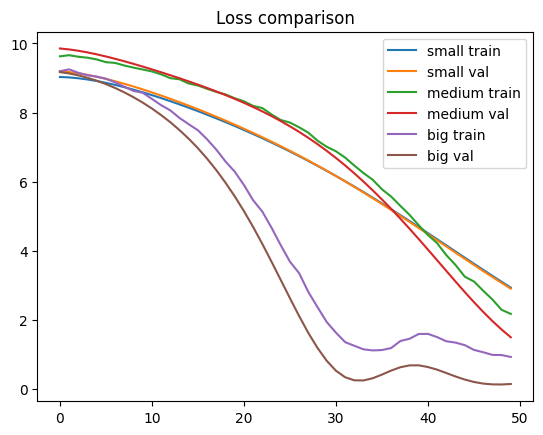

In [26]:
import matplotlib.pyplot as plt

for name, (train_loss, val_loss) in results.items():
    plt.plot(train_loss, label=f"{name} train")
    plt.plot(val_loss, label=f"{name} val")

plt.legend()
plt.title("Loss comparison")
plt.show()

In [37]:
import ssl
import certifi
import os
import urllib.request

# Супер-жесткое отключение SSL проверки
ssl._create_default_https_context = ssl._create_unverified_context

# Дополнительно отключаем через urllib
import warnings
warnings.filterwarnings('ignore')

# Принудительно устанавливаем контекст для всех HTTPS запросов
old_init = urllib.request.OpenerDirector.__init__
def new_init(self):
    old_init(self)
    self.add_handler(urllib.request.HTTPSHandler(context=ssl._create_unverified_context()))
urllib.request.OpenerDirector.__init__ = new_init

# Теперь ваш код
from sklearn.datasets import fetch_openml
import numpy as np

print("Загрузка MNIST...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data / 255.0
y = mnist.target.astype(int)

X = X.values.reshape(-1, 1, 28, 28)
def train_val_split(X, y, ratio=0.8):
    idx = int(len(X) * ratio)
    return X[:idx], X[idx:], y[:idx], y[idx:]

X_train, X_val, y_train, y_val = train_val_split(X, y)
X_train = X_train[:2500]
y_train = y_train[:2500]
X_val = X_val[:700]
y_val = y_val[:700]
# one-hot
def one_hot(y, num_classes=10):
    out = np.zeros((len(y), num_classes))
    out[np.arange(len(y)), y] = 1
    return out

y_train_oh = one_hot(y_train)
y_val_oh = one_hot(y_val)

model = Sequential()

model.add(Conv2d(1, 8, 3, padding=0))
model.add(ReLU())
model.add(MaxPool2d(2, 2))

model.add(Flatten())

model.add(Linear(8 * 13 * 13, 128))
model.add(ReLU())

model.add(Linear(128, 10))
model.add(LogSoftMax())

Загрузка MNIST...


In [38]:
criterion = ClassNLLCriterion()

def accuracy(model, X, y):
    preds = model.forward(X)
    return (np.argmax(preds, axis=1) == np.argmax(y, axis=1)).mean()
class LRScheduler:
    def __init__(self, optimizer, base_lr, warmup_epochs=5, decay=0.95):
        self.optimizer = optimizer
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
        self.decay = decay
        self.epoch = 0

    def step(self):
        self.epoch += 1

        if self.epoch < self.warmup_epochs:
            lr = self.base_lr * (self.epoch / self.warmup_epochs)
        else:
            lr = self.base_lr * (self.decay ** (self.epoch - self.warmup_epochs))

        self.optimizer.lr = lr

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0

    def step(self, loss):
        if loss < self.best_loss:
            self.best_loss = loss
            self.counter = 0
            return True  
        else:
            self.counter += 1
            return False

    def should_stop(self):
        return self.counter >= self.patience


In [39]:


def train(model, X_train, y_train, X_val, y_val, epochs=10):

    optimizer = SGD(model, lr=1e-3)
    scheduler = LRScheduler(optimizer, base_lr=1e-3)
    early_stop = EarlyStopping(patience=5)

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_model = None

    for epoch in range(epochs):

        model.train()

        # forward
        out = model.forward(X_train)
        loss = criterion.forward(out, y_train)

        # backward
        grad = criterion.backward(out, y_train)
        model.backward(X_train, grad)

        optimizer.step()
        optimizer.zero_grad()

        # validation
        model.evaluate()
        val_out = model.forward(X_val)
        val_loss = criterion.forward(val_out, y_val)
        val_acc = accuracy(model, X_val, y_val)

        train_losses.append(loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch}: train={loss:.4f}, val={val_loss:.4f}, acc={val_acc:.4f}")

        scheduler.step()

        if early_stop.step(val_loss):
            best_model = model

        if early_stop.should_stop():
            print("Early stopping!")
            break

    return train_losses, val_losses, val_accuracies, best_model


In [40]:
import matplotlib.pyplot as plt

def plot_loss(train_losses, val_losses):
    plt.plot(train_losses, label="train loss")
    plt.plot(val_losses, label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss")
    plt.show()


def plot_accuracy(val_accuracies):
    plt.plot(val_accuracies, label="val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy")
    plt.show()


Epoch 0: train=2.3046, val=2.3000, acc=0.0960
Epoch 1: train=2.3045, val=2.2998, acc=0.0960
Epoch 2: train=2.3043, val=2.2996, acc=0.0970
Epoch 3: train=2.3041, val=2.2994, acc=0.0990
Epoch 4: train=2.3038, val=2.2990, acc=0.0990
Epoch 5: train=2.3035, val=2.2986, acc=0.1000
Epoch 6: train=2.3030, val=2.2980, acc=0.1000
Epoch 7: train=2.3024, val=2.2974, acc=0.1010
Epoch 8: train=2.3018, val=2.2967, acc=0.1010
Epoch 9: train=2.3011, val=2.2960, acc=0.1020


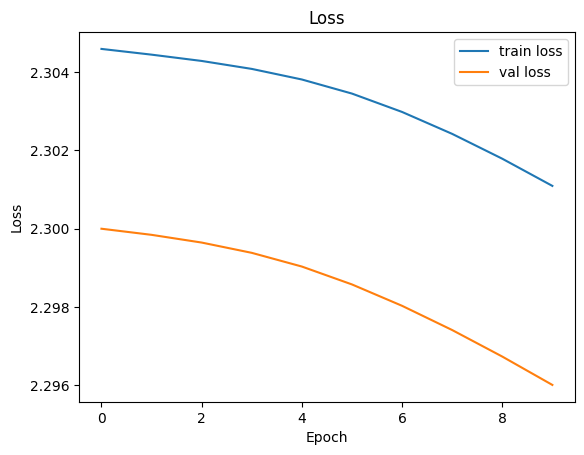

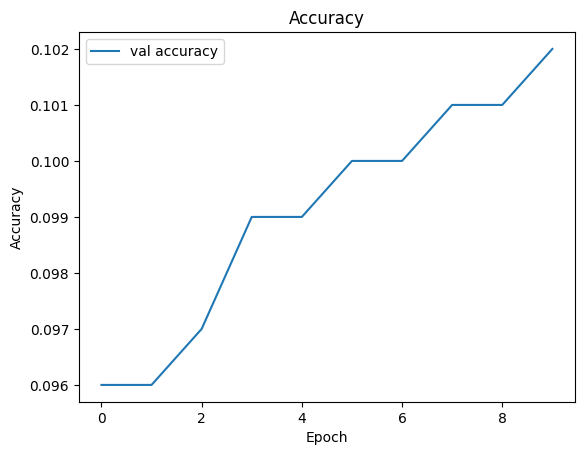

In [31]:
train_losses, val_losses, val_acc, best_model = train(
model, 
X_train, y_train_oh,
X_val, y_val_oh, 
 epochs=10
 )
plot_loss(train_losses, val_losses)
plot_accuracy(val_acc)

In [41]:
class Upsample(Module):
    def __init__(self, scale):
        super().__init__()
        self.scale = scale

    def updateOutput(self, input):
        self.output = np.repeat(np.repeat(input, self.scale, axis=2), self.scale, axis=3)
        return self.output

    def updateGradInput(self, input, gradOutput):
        s = self.scale
        N, C, H, W = input.shape

        self.gradInput = gradOutput.reshape(N, C, H, s, W, s).sum(axis=(3,5))
        return self.gradInput

    def __repr__(self):
        return "Upsample"


In [42]:
def build_autoencoder():
    model = Sequential()
    model.add(Conv2d(1, 16, 3, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(2, 2))  # 28 - 14

    model.add(Conv2d(16, 32, 3, padding=1))
    model.add(ReLU())
    model.add(MaxPool2d(2, 2))  # 14 - 7

    model.add(Upsample(2))  # 7 - 14
    model.add(Conv2d(32, 16, 3, padding=1))
    model.add(ReLU())

    model.add(Upsample(2))  # 14 - 28
    model.add(Conv2d(16, 1, 3, padding=1))

    return model

In [43]:
def train_autoencoder(model, X_train, X_val, epochs=20):

    optimizer = SGD(model, lr=1e-3)
    scheduler = LRScheduler(optimizer, base_lr=1e-3)
    early_stop = EarlyStopping(patience=5)

    train_losses = []
    val_losses = []

    best_model = None

    for epoch in range(epochs):
        model.train()

        out = model.forward(X_train)
        loss = ae_criterion.forward(out, X_train)

        grad = ae_criterion.backward(out, X_train)
        model.backward(X_train, grad)

        optimizer.step()
        optimizer.zero_grad()

        model.evaluate()
        val_out = model.forward(X_val)
        val_loss = ae_criterion.forward(val_out, X_val)

        train_losses.append(loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}: train={loss:.4f}, val={val_loss:.4f}")

        scheduler.step()

        if early_stop.step(val_loss):
            best_model = model

        if early_stop.should_stop():
            print("Early stopping!")
            break

    return train_losses, val_losses, best_model



In [44]:
def plot_ae(train_losses, val_losses):
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.legend()
    plt.title("Autoencoder Loss")
    plt.show()

def show_reconstruction(model, X):
    model.evaluate()

    out = model.forward(X[:5])

    for i in range(5):
        plt.subplot(2, 5, i+1)
        plt.imshow(X[i, 0], cmap='gray', interpolation='bilinear')
        plt.title("Input")
        plt.axis('off')

        plt.subplot(2, 5, i+6)
        plt.imshow(out[i, 0], cmap='gray', interpolation='bilinear')
        plt.title("Recon")
        plt.axis('off')
 
    plt.tight_layout()
    plt.show()

Epoch 0: train=84.5698, val=285.6884
Epoch 1: train=288.1119, val=76.3464
Epoch 2: train=79.6294, val=72.3315
Epoch 3: train=75.4913, val=70.9618
Epoch 4: train=73.8315, val=69.5870


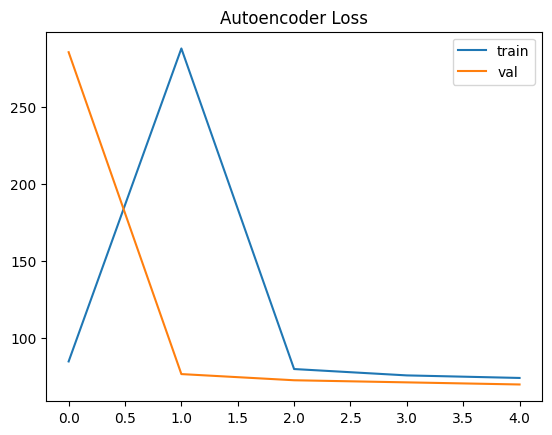

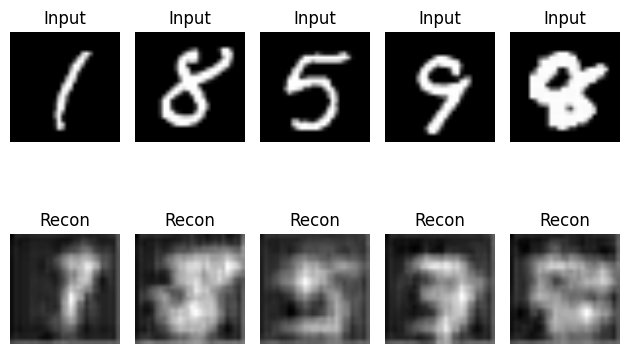

In [45]:
ae_criterion = MSECriterion()
ae_model = build_autoencoder()

train_losses, val_losses, best_ae = train_autoencoder(
    ae_model, X_train, X_val, epochs=5
)

plot_ae(train_losses, val_losses)

show_reconstruction(best_ae, X_val)
